In [1]:
import csv 
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [4]:
# CSV generation for java data
dataframe = [["Code", "Label"]]

for filename in os.listdir("./java/train_data/blob/positive"):
    filepath = os.path.join("./java/train_data/blob/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 1]
        dataframe.append(newInstance)
        
for filename in os.listdir("./java/train_data/blob/negative"):
    filepath = os.path.join("./java/train_data/blob/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 0]
        dataframe.append(newInstance)
        
with open("./java/train_data/blob/traindata.csv", mode = "w" , newline = '', encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(dataframe)


In [2]:
# CSV generation for javascript data

#                   code smells labels
# long parameters: 0
# long methods: 1
# empty catch: 2
# complex functions: 3
# multiple return statements: 4


dataframe = [["Code", "Label"]]

for filename in os.listdir("./javascript/train_data/long parameters"):
    filepath = os.path.join("./javascript/train_data/long parameters/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 0]
        dataframe.append(newInstance)
        
for filename in os.listdir("./javascript/train_data/long methods"):
    filepath = os.path.join("./javascript/train_data/long methods/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 1]
        dataframe.append(newInstance)
        
for filename in os.listdir("./javascript/train_data/empty catch"):
    filepath = os.path.join("./javascript/train_data/empty catch/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 2]
        dataframe.append(newInstance)
        
for filename in os.listdir("./javascript/train_data/complex functions"):
    filepath = os.path.join("./javascript/train_data/complex functions/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 3]
        dataframe.append(newInstance)
        
for filename in os.listdir("./javascript/train_data/multiple return statements"):
    filepath = os.path.join("./javascript/train_data/multiple return statements/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        newInstance = [file.read(), 4]
        dataframe.append(newInstance)
        
with open("./javascript/train_data/traindata.csv", mode = "w" , newline = '', encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerows(dataframe)

In [8]:
df = pd.read_csv("./java/train_data/blob/traindata.csv", encoding="utf-8")
df
# labeldf = df[df["Label"] == 0]
# labeldf

,Code,Label
0,public final class SwiftUtils {\n\n public st...,1
1,public static class Builder {\n\n f...,1
2,public abstract class AbstractControllerServic...,1
3,public class JavadocFormatter {\n\n private...,1
4,@Singleton\npublic class StandardComponentInit...,1
...,...,...
1196,/*package*/ class WafFolderContent {\n privat...,0
1197,interface ToolWindows {\n String TOOL...,0
1198,@AutoValue\nabstract class UOfKind extends UEx...,0
1199,public abstract class FakeMediaClockRenderer e...,0


In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from transformers import AdamW
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd

df = pd.read_csv("traindata.csv", encoding="utf-8")

# splitting the dataset into train and test portions

train_codetexts, test_codetexts, train_labels, test_labels = train_test_split(
    df["Code"], df["Label"], shuffle=True,
    test_size=0.15
)

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")

# tokenizing the both train and test samples

train_tokens = tokenizer(train_codetexts.tolist(), padding=True, truncation=True, return_tensors="pt")
test_tokens = tokenizer(test_codetexts.tolist(), padding=True, truncation=True, return_tensors="pt")


# initializing the codebert model
model = AutoModelForSequenceClassification.from_pretrained("microsoft/graphcodebert-base", num_labels=2)

optimizer = AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

# creating a class to handle our data set
class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)
    
    
# creating proper format of data
train_dataset = TextDataset(train_tokens, train_labels.tolist())
test_dataset = TextDataset(test_tokens, test_labels.tolist())

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

device = torch.device("cuda")
model.to(device)

epochs = 5

for epoch in range(epochs):
  model.train()
  for batch in train_loader:
      batch = {k: v.to(device) for k, v in batch.items()}
      outputs = model(**batch)
      logits = outputs.logits 
      labels = batch['labels'].to(device)
      loss = criterion(logits, labels)
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

    
print("training complete")
print()

# Evaluating or testing the trained model
model.eval()

total_eval_accuracy = 0

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        accuracy = (predictions == batch['labels']).cpu().numpy().mean() * 100
        total_eval_accuracy += accuracy

# Calculate average validation accuracy
avg_val_accuracy = total_eval_accuracy / len(test_loader)
print(f"Accuracy: {avg_val_accuracy:.2f}%")

True_Positives :  29
True_Negatives :  28
False_Positives :  5
False_Negatives :  1


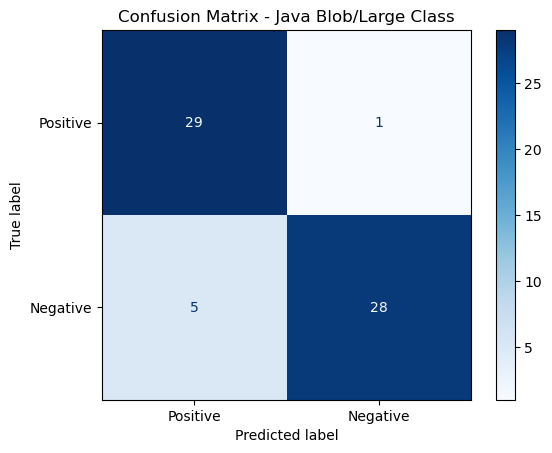



Recall: 0.97
F1_Score: 0.91


In [6]:
# prediction from the trained model for java blob
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./java_blob")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./java/validation_data/blob/positive"):
    filepath = os.path.join("./java/validation_data/blob/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./java/validation_data/blob/negative"):
    filepath = os.path.join("./java/validation_data/blob/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Blues')
plt.title("Confusion Matrix - Java Blob/Large Class")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  21
True_Negatives :  37
False_Positives :  4
False_Negatives :  2


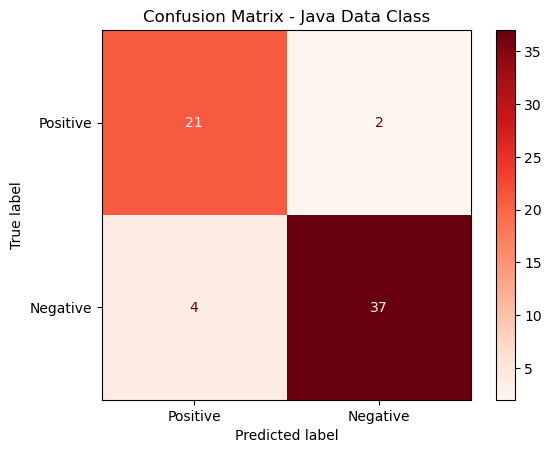



Recall: 0.91
F1_Score: 0.88


In [7]:
# prediction from the trained model for java Data Class
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./java_data_class")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./java/validation_data/data class/positive"):
    filepath = os.path.join("./java/validation_data/data class/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./java/validation_data/data class/negative"):
    filepath = os.path.join("./java/validation_data/data class/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Reds')
plt.title("Confusion Matrix - Java Data Class")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  33
True_Negatives :  26
False_Positives :  4
False_Negatives :  5


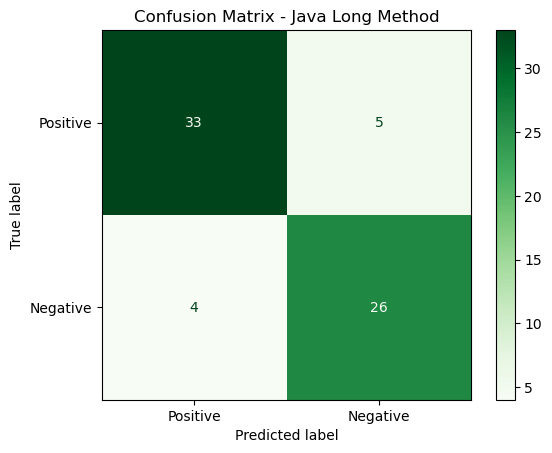



Recall: 0.87
F1_Score: 0.88


In [8]:
# prediction from the trained model for java long method
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./java_long_method")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./java/validation_data/long method/positive"):
    filepath = os.path.join("./java/validation_data/long method/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./java/validation_data/long method/negative"):
    filepath = os.path.join("./java/validation_data/long method/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Greens')
plt.title("Confusion Matrix - Java Long Method")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  50
True_Negatives :  58
False_Positives :  1
False_Negatives :  0


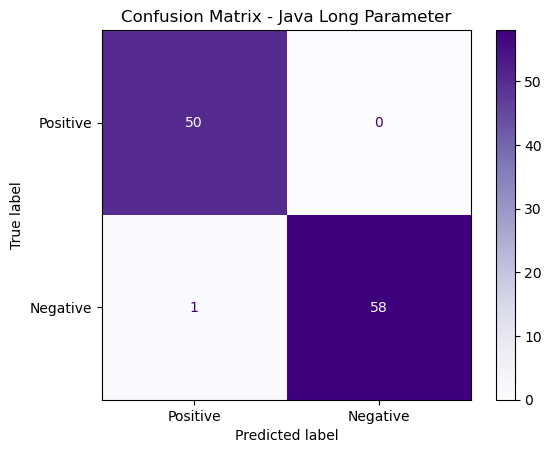



Recall: 1.00
F1_Score: 0.99


In [9]:
# prediction from the trained model for java long parameter
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./java_long_parameter")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./java/validation_data/long parameter/positive"):
    filepath = os.path.join("./java/validation_data/long parameter/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./java/validation_data/long parameter/negative"):
    filepath = os.path.join("./java/validation_data/long parameter/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Purples')
plt.title("Confusion Matrix - Java Long Parameter")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  33
True_Negatives :  25
False_Positives :  4
False_Negatives :  6


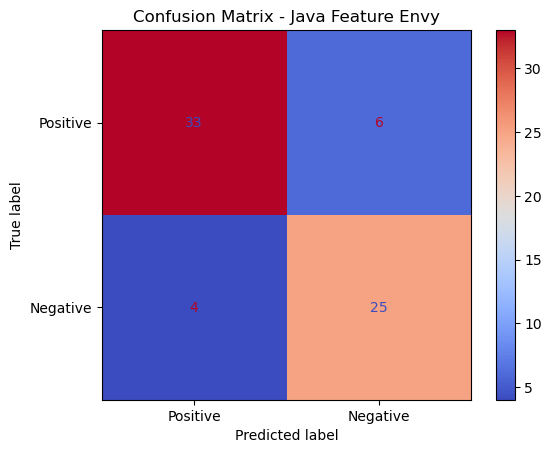



Recall: 0.85
F1_Score: 0.87


In [11]:
# prediction from the trained model for java Feature Envy
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./java_feature_envy")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./java/validation_data/feature envy/positive"):
    filepath = os.path.join("./java/validation_data/feature envy/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./java/validation_data/feature envy/negative"):
    filepath = os.path.join("./java/validation_data/feature envy/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='coolwarm')
plt.title("Confusion Matrix - Java Feature Envy")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  20
True_Negatives :  19
False_Positives :  1
False_Negatives :  0


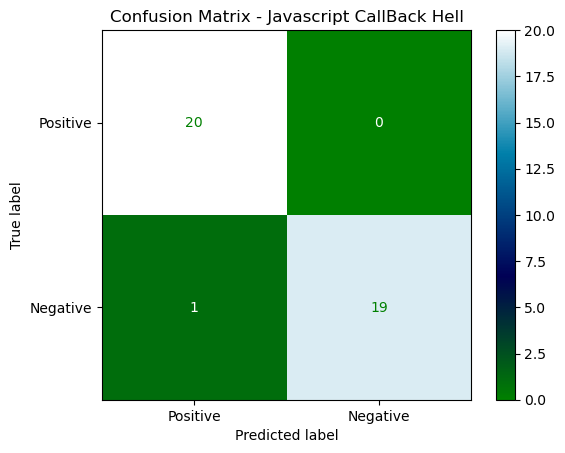



Recall: 1.00
F1_Score: 0.98


In [15]:
# prediction from the trained model for javascript Callback Hell
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./js_callback_graphcodebert")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./javascript/validation_data/callback hell/positive"):
    filepath = os.path.join("./javascript/validation_data/callback hell/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./javascript/validation_data/callback hell/negative"):
    filepath = os.path.join("./javascript/validation_data/callback hell/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='ocean')
plt.title("Confusion Matrix - Javascript CallBack Hell")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  12
True_Negatives :  10
False_Positives :  0
False_Negatives :  5


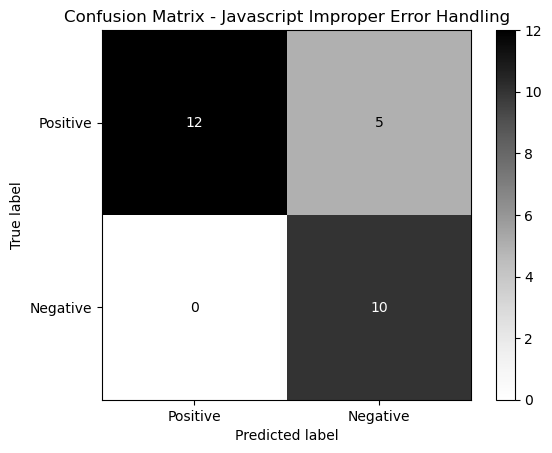



Recall: 0.71
F1_Score: 0.83


In [16]:
# prediction from the trained model for javascript Improper Error Handling
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./js_impropererror_codebert")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./javascript/validation_data/improper error handling/positive"):
    filepath = os.path.join("./javascript/validation_data/improper error handling/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./javascript/validation_data/improper error handling/negative"):
    filepath = os.path.join("./javascript/validation_data/improper error handling/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Greys')
plt.title("Confusion Matrix - Javascript Improper Error Handling")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

True_Positives :  9
True_Negatives :  9
False_Positives :  1
False_Negatives :  1


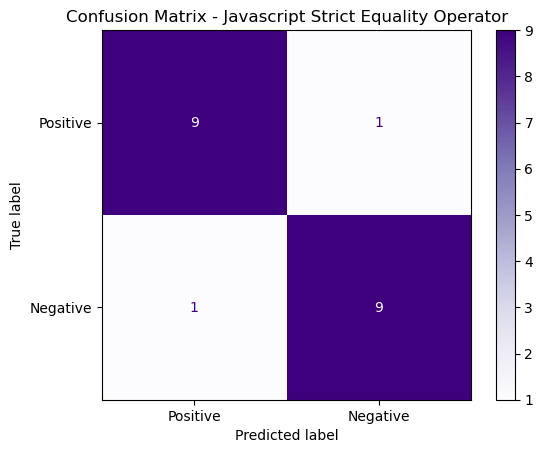



Recall: 0.90
F1_Score: 0.90


In [17]:
# prediction from the trained model for javascript Strict Equality Operator
import joblib
import torch
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("microsoft/graphcodebert-base")
model = joblib.load("./js_strictequality_codebert")
model.eval()

true_positives = 0
false_negatives = 0
true_negatives = 0
false_positives = 0

# print()
# print("Inference for Positive Samples")
# print()
# print()
# print()

for filename in os.listdir("./javascript/validation_data/strict equality/positive"):
    filepath = os.path.join("./javascript/validation_data/strict equality/positive/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 1:
            true_positives = true_positives + 1
        else :
            false_negatives = false_negatives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()

        
# print()
# print()
# print("Inference for Negative Samples")
# print()
# print()
# print()    
        
for filename in os.listdir("./javascript/validation_data/strict equality/negative"):
    filepath = os.path.join("./javascript/validation_data/strict equality/negative/", filename)
    with open (filepath, "r" , encoding = "utf-8") as file:
        tokenizedInput = tokenizer(file.read(), padding=True, truncation=True ,return_tensors="pt")
        input_ids = tokenizedInput['input_ids'].to(model.device)
        attention_mask = tokenizedInput['attention_mask'].to(model.device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=-1)
        predicted_labels = torch.argmax(probabilities, dim=-1)
        if predicted_labels == 0:
            true_negatives = true_negatives + 1
        else :
            false_positives = false_positives + 1
        
#         print(filename)
#         print(predicted_labels.item())
#         print()
        

print("True_Positives : ", true_positives)
print("True_Negatives : ", true_negatives)
print("False_Positives : ", false_positives)
print("False_Negatives : ", false_negatives)

recall = true_positives / (true_positives + false_negatives)

confusion_matrix = np.array([
    [true_positives, false_negatives],
    [false_positives, true_negatives]
])

confusion_matrix_df = pd.DataFrame(
    confusion_matrix, 
    index=["Actual Positive", "Actual Negative"], 
    columns=["Predicted Positive", "Predicted Negative"]
)

display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=["Positive", "Negative"])
display.plot(cmap='Purples')
plt.title("Confusion Matrix - Javascript Strict Equality Operator")
plt.show()

print()
print()
print(f"Recall: {recall:.2f}")
F1_Score = (2 * true_positives) / ((2 * true_positives) + false_negatives + false_positives)
print(f"F1_Score: {F1_Score:.2f}")

In [ ]:
# updated training code for handling longer sequences

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from transformers import AdamW
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import pandas as pd

# Load dataset
df = pd.read_csv("traindata.csv", encoding="utf-8")

# Split the dataset into train and test portions
train_codetexts, test_codetexts, train_labels, test_labels = train_test_split(
    df["Code"], df["Label"], shuffle=True, test_size=0.18
)

# Initialize tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
base_model = AutoModel.from_pretrained("microsoft/codebert-base")

# Define the segmenting and combining functions
def segment_code(code, tokenizer, max_length=512):
    tokens = tokenizer.tokenize(code)
    segments = []
    for i in range(0, len(tokens), max_length):
        segments.append(tokens[i:i+max_length])
    return segments

def get_segment_representations(segments):
    segment_representations = []
    for segment in segments:
        segment_text = tokenizer.convert_tokens_to_string(segment)
        inputs = tokenizer.encode_plus(segment_text, return_tensors="pt", padding="max_length", max_length=512, truncation=True)
        inputs = {key: val.to(device) for key, val in inputs.items()}
        outputs = base_model(**inputs)
        segment_representations.append(outputs.last_hidden_state[:, 0, :])
    return segment_representations

def average_representations(representations):
    return torch.mean(torch.stack(representations), dim=0)

# Creating a class to handle our dataset
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        code = self.texts[idx]
        segments = segment_code(code, self.tokenizer)
        segment_representations = get_segment_representations(segments)
        global_representation = average_representations(segment_representations)

        return {'embedding': global_representation, 'labels': torch.tensor(self.labels[idx])}

    def __len__(self):
        return len(self.labels)

# Creating proper format of data
train_dataset = TextDataset(train_codetexts.tolist(), train_labels.tolist(), tokenizer)
test_dataset = TextDataset(test_codetexts.tolist(), test_labels.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

device = torch.device("cuda")

# Define a custom classifier on top of the average representations
class CustomClassifier(nn.Module):
    def __init__(self, base_model, hidden_size):
        super(CustomClassifier, self).__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(hidden_size, 1)

    def forward(self, input_ids):
        logits = self.classifier(input_ids)
        return logits

model = CustomClassifier(base_model, hidden_size=768)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.BCEWithLogitsLoss()

def adjust_labels(labels):
    return labels.unsqueeze(1).float()

epochs = 2

for epoch in range(epochs):
    model.train()
    for batch in train_loader:
        inputs = batch['embedding'].to(device)
        labels = adjust_labels(batch['labels']).to(device)
        outputs = model(inputs).squeeze(-1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

print("Training complete")

# Evaluating or testing the trained model
model.eval()
total_eval_accuracy = 0

with torch.no_grad():
    for batch in test_loader:
        inputs = batch['embedding'].to(device)
        labels = batch['labels'].to(device)
        outputs = model(inputs)
        predictions = torch.argmax(outputs, dim=-1)
        accuracy = (predictions == labels).cpu().numpy().mean() * 100
        total_eval_accuracy += accuracy

# Calculate average validation accuracy
avg_val_accuracy = total_eval_accuracy / len(test_loader)
print(f"Accuracy: {avg_val_accuracy:.2f}%")
